# Control Question Tier Analysis

Characterises the 1K control question pool by tier (A–E) and entity/op group.
Generates `analysis/csv/sampled_control_questions.csv` — used as input by `question_sampling.ipynb`.

**Tiers:**

| Tier | Criterion | Failure mode |
|------|-----------|--------------|
| A | conf > 0.75 AND acc < 0.2 (baseline) | Overconfident wrong — hallucination |
| B | mean unique outputs > 2 across control variants | Answer flip — linguistically sensitive |
| C | ≥ 80% models wrong on baseline | Consensus wrong — shared corpus prior |
| D | acc_drop (baseline→pronominalized) > 0.3 | High accuracy degradation |
| E | conf_drop > 0.05 AND acc_baseline > 0.5 | High confidence degradation |


In [ ]:
import json
import pandas as pd
import numpy as np
import os
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

RESULTS_DIR    = '/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained'
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'

mapper = VQAAnswerMapper()

# Full 5-step degradation ladder (pronominalized now complete for all models below)
CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']
# Degradation endpoint for Tier D/E (full pronoun ablation — steepest drop)
ABLATED_KEY   = 'pronominalized'

# Models with complete vqa_1k_control.jsonl (all 5 CONTROL_TYPES, 1000 records).
# Incomplete: Qwen3-VL-8B (only pronominalized), llava-v1.6-mistral-7b-hf (12 recs), Qwen3-VL-32B (43 recs)
COMPLETE_MODELS = [
    'InternVL3_5-1B',
    'InternVL3_5-2B',
    'InternVL3_5-8B',
    'Qwen3-VL-2B-Instruct',
    'Qwen3-VL-4B-Instruct',
    'llava-1.5-7b-hf',
    'llava-v1.6-vicuna-13b-hf',
    'llava-v1.6-vicuna-7b-hf',
]

sem_df = pd.read_json(SEMANTICS_PATH, lines=True)[['question_id', 'ent', 'w', 'op', 'attr', 'ans']]
qid_to_ent = dict(zip(sem_df['question_id'], sem_df['ent']))
qid_to_op  = dict(zip(sem_df['question_id'], sem_df['op']))


In [2]:
def load_control(model, dataset='vqa_1k_control'):
    filepath = f'{RESULTS_DIR}/{model}/{dataset}.jsonl'
    if not os.path.exists(filepath):
        return []
    rows = []
    with open(filepath) as f:
        for line in f:
            ex = json.loads(line)
            if 'generated_logits' not in ex:
                continue
            gt_answers = mapper.get_answers(ex['question_id'])
            ent = qid_to_ent.get(ex['question_id'], 'other')
            for ct in ex['generated_logits']:
                logits = ex['generated_logits'][ct]['content']
                token_probs = np.exp([t['logprob'] for t in logits])
                confidence = float(token_probs.mean())
                output = (ex.get('generated_answers') or {}).get(ct, '')
                accuracy = vqa_accuracy(output, gt_answers) if gt_answers else None
                rows.append({
                    'model': model,
                    'question_id': ex['question_id'],
                    'control_type': ct,
                    'question_text': ex.get(ct, ''),
                    'output': output,
                    'confidence': confidence,
                    'accuracy': accuracy,
                    'ent': ent,
                    'gt_answer': gt_answers
                })
    return rows

all_rows = []
for m in COMPLETE_MODELS:
    rows = load_control(m)
    print(f"  {m}: {len(rows)} rows ({len(rows)//max(len(CONTROL_TYPES),1) if rows else 0} questions approx)")
    all_rows.extend(rows)

df = pd.DataFrame(all_rows)
df['accuracy'] = pd.to_numeric(df['accuracy'], errors='coerce')

# Keep base 4 control types + pronominalized (ablation endpoint); drop deprecated subject_ablated
LOAD_TYPES = CONTROL_TYPES + ([ABLATED_KEY] if ABLATED_KEY not in CONTROL_TYPES else [])
df = df[df['control_type'].isin(LOAD_TYPES)]

print(f'\nTotal: {len(df)} rows | {df["model"].nunique()} models | {df["question_id"].nunique()} questions')
print(f'Control types loaded: {sorted(df["control_type"].unique())}')
print(f'\nModel × question coverage:')
print(df[df["control_type"]=="question"].groupby("model")["question_id"].nunique())

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
  llava-v1.6-vicuna-7b-hf: 6000 rows (1500 questions approx)
  llava-v1.6-vicuna-13b-hf: 6000 rows (1500 questions approx)
  Qwen3-VL-2B-Instruct: 6000 rows (1500 questions approx)
  Qwen3-VL-4B-Instruct: 6000 rows (1500 questions approx)

Total: 20000 rows | 4 models | 1000 questions
Control types loaded: ['deictic_removed', 'object_removed', 'pronominalized', 'question', 'weaker_object']

Model × question coverage:
model
Qwen3-VL-2B-Instruct        1000
Qwen3-VL-4B-Instruct        1000
llava-v1.6-vicuna-13b-hf    1000
llava-v1.6-vicuna-7b-hf     1000
Name: question_id, dtype: int64


In [ ]:
# Model coverage summary
print("=== Model Coverage (vqa_1k_control) ===")
print("\nCOMPLETE (all 5 control types, 1000 records):")
for m in COMPLETE_MODELS:
    print(f"  ✓ {m}")
print("\nINCOMPLETE:")
incomplete = [
    ('Qwen3-VL-8B-Instruct',     'only pronominalized (1000 recs — re-run needed for full control)'),
    ('llava-v1.6-mistral-7b-hf', 'only 12 records (inference partial)'),
    ('Qwen3-VL-32B-Instruct',    'only 43 records, missing pronominalized'),
]
for m, reason in incomplete:
    print(f"  ✗ {m}  [{reason}]")

print(f"\n{len(COMPLETE_MODELS)} complete models | 5-step degradation ladder: {CONTROL_TYPES}")


In [ ]:
# Aggregate per (question_id, control_type) across all complete models
agg = df.groupby(['question_id', 'control_type', 'ent']).agg(
    mean_accuracy=('accuracy', 'mean'),
    mean_confidence=('confidence', 'mean'),
    n_models=('model', 'nunique'),
    outputs=('output', lambda x: list(x)),
).reset_index()

baseline = agg[agg['control_type'] == 'question'][['question_id', 'mean_accuracy', 'mean_confidence', 'ent']]
baseline.columns = ['question_id', 'acc_baseline', 'conf_baseline', 'ent']
ablated = agg[agg['control_type'] == ABLATED_KEY][['question_id', 'mean_accuracy', 'mean_confidence']]
ablated.columns = ['question_id', 'acc_ablated', 'conf_ablated']

qdf = baseline.merge(ablated, on='question_id')
qdf['acc_drop']  = qdf['acc_baseline'] - qdf['acc_ablated']
qdf['conf_drop'] = qdf['conf_baseline'] - qdf['conf_ablated']

# Tier A — overconfident & wrong
qdf['overconfident_wrong'] = (qdf['conf_baseline'] > 0.75) & (qdf['acc_baseline'] < 0.2)

# Tier B — answer flip across control variants
flip = df[df['control_type'].isin(CONTROL_TYPES)].groupby(['question_id', 'model']).apply(
    lambda g: g.set_index('control_type')['output'].reindex(CONTROL_TYPES).nunique(dropna=True)
).reset_index()
flip.columns = ['question_id', 'model', 'n_unique_outputs']
flip_agg = flip.groupby('question_id')['n_unique_outputs'].mean().reset_index()
flip_agg.columns = ['question_id', 'mean_output_changes']

# Tier C — majority of models wrong on baseline
consensus = (
    df[df['control_type'] == 'question']
    .groupby('question_id')
    .apply(lambda g: (g['accuracy'] < 0.2).mean())
    .reset_index()
)
consensus.columns = ['question_id', 'frac_models_wrong']
consensus['consensus_wrong'] = consensus['frac_models_wrong'] >= 0.8

qdf = qdf.merge(flip_agg, on='question_id').merge(
    consensus[['question_id', 'consensus_wrong', 'frac_models_wrong']], on='question_id'
)

# ── Compute n_distinct (flat question filter) ────────────────────────────────
CONTROL_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_control.jsonl'
CT5 = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']

nd_rows = []
with open(CONTROL_PATH) as f:
    for line in f:
        ex = json.loads(line)
        texts = {ex.get(ct, '').strip().lower() for ct in CT5 if ex.get(ct, '').strip()}
        nd_rows.append({'question_id': ex['question_id'], 'n_distinct': len(texts)})
nd_df = pd.DataFrame(nd_rows)

qdf = qdf.merge(nd_df, on='question_id', how='left')
qdf['n_distinct'] = qdf['n_distinct'].fillna(-1).astype(int)

# Save full qdf before filtering so we can show tier impact
qdf_all = qdf.copy()
flat_ids = set(qdf[qdf['n_distinct'] == 1]['question_id'])

# Remove flat questions from all sampling pools
qdf = qdf[qdf['n_distinct'] > 1].copy()

print(f"Loaded {len(qdf_all)} questions | {df['model'].nunique()} models: {sorted(df['model'].unique())}")
print(f"Degradation endpoint: '{ABLATED_KEY}'")
print(f"\nFlat questions removed (all 5 CTs identical): {len(flat_ids)}")
print(f"Remaining for sampling: {len(qdf)}")
# Add op, ent_grp, op_grp, cell columns
qdf = qdf.merge(sem_df[['question_id', 'op']], on='question_id', how='left')

ENT_COLLAPSE = {
    'object': 'object', 'person': 'person', 'animal': 'animal',
    'food': 'scene',   'place': 'scene',   'vehicle': 'scene',
    'other': 'other',  'text': 'other',    'product': 'other',
}
OP_COLLAPSE = {
    'attr': 'attr',    'count': 'count',
    'exist': 'local',  'spat': 'local',
    'ident': 'recog',  'act': 'recog',
    'text': 'other_op','know': 'other_op','comp': 'other_op',
    'cause': 'other_op','temp': 'other_op','other': 'other_op',
}
qdf['ent_grp'] = qdf['ent'].map(ENT_COLLAPSE).fillna('other')
qdf['op_grp']  = qdf['op'].map(OP_COLLAPSE).fillna('other_op')
qdf['cell']    = qdf['ent_grp'] + '|' + qdf['op_grp']

# Composite signal score per question (using acc_drop and n_distinct as proxies pre-logit)
# Full signal_score (from logits) is added after loading control signals in the script;
# here we use acc_drop + mean_output_changes as the notebook's in-memory signal.
qdf['signal_score'] = (
    0.6 * (qdf['acc_drop'].clip(0).rank(pct=True)) +
    0.4 * (qdf['mean_output_changes'].rank(pct=True))
)

print(f"qdf shape: {qdf.shape}")
print("\nEnt group distribution:")
print(qdf['ent_grp'].value_counts())
print("\nOp group distribution:")
print(qdf['op_grp'].value_counts())
print("\nCell sizes (ent_grp × op_grp):")
print(qdf.groupby(['ent_grp','op_grp']).size().unstack(fill_value=0))
qdf.head()

=== Tier Pool Sizes — Before vs After Flat Removal ===

  Tier A  overconfident & wrong  (conf>0.75, acc<0.2)
    before:   36  after:   33  flat removed: 3 (8.3%)  ← notable

  Tier B  answer flip  (mean unique > 2)
    before:   58  after:   58  flat removed: 0 (0.0%)

  Tier C  consensus wrong  (≥80% models)
    before:   34  after:   28  flat removed: 6 (17.6%)  ← notable

  Tier D  high acc drop  (>0.3)
    before:  167  after:  167  flat removed: 0 (0.0%)

  Tier E  high conf drop (>0.05, acc>0.5)
    before:  219  after:  218  flat removed: 1 (0.5%)

Total flat removed: 75 / 1000 (7.5%)
Sampling pool size: 925

=== Criterion Counts (flat-filtered pool) ===
A. Overconfident & Wrong (conf>0.75, acc<0.2):        33
B. Answer flip (mean unique outputs > 2):             58
C. Consensus wrong (≥80% models wrong on baseline):  28
D. High accuracy drop (acc_drop > 0.3):              167
E. High confidence drop (conf_drop > 0.05, acc>0.5): 218

Entity distribution (flat-filtered):
ent
ob

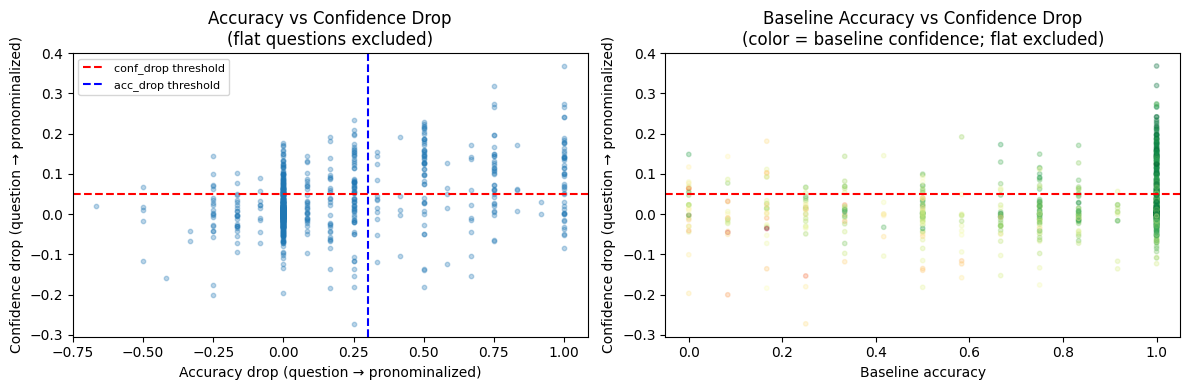

In [5]:
print('=== Tier Pool Sizes — Before vs After Flat Removal ===\n')
tier_masks = {
    'A  overconfident & wrong  (conf>0.75, acc<0.2)':
        ('overconfident_wrong',      lambda q: q['overconfident_wrong']),
    'B  answer flip  (mean unique > 2)':
        ('mean_output_changes>2',    lambda q: q['mean_output_changes'] > 2),
    'C  consensus wrong  (≥80% models)':
        ('consensus_wrong',          lambda q: q['consensus_wrong']),
    'D  high acc drop  (>0.3)':
        ('acc_drop>0.3',             lambda q: q['acc_drop'] > 0.3),
    'E  high conf drop (>0.05, acc>0.5)':
        ('conf_drop>0.05',           lambda q: (q['conf_drop'] > 0.05) & (q['acc_baseline'] > 0.5)),
}

for label, (_, mask_fn) in tier_masks.items():
    n_before = mask_fn(qdf_all).sum()
    n_after  = mask_fn(qdf).sum()
    n_flat   = n_before - n_after
    pct      = n_flat / n_before * 100 if n_before > 0 else 0
    flag     = '  ← notable' if pct >= 5 else ''
    print(f'  Tier {label}')
    print(f'    before: {n_before:4d}  after: {n_after:4d}  flat removed: {n_flat} ({pct:.1f}%){flag}')
    print()

print(f'Total flat removed: {len(flat_ids)} / {len(qdf_all)} ({len(flat_ids)/len(qdf_all)*100:.1f}%)')
print(f'Sampling pool size: {len(qdf)}')
print()
print('=== Criterion Counts (flat-filtered pool) ===')
print(f"A. Overconfident & Wrong (conf>0.75, acc<0.2):        {qdf['overconfident_wrong'].sum()}")
print(f"B. Answer flip (mean unique outputs > 2):             {(qdf['mean_output_changes'] > 2).sum()}")
print(f"C. Consensus wrong (≥80% models wrong on baseline):  {qdf['consensus_wrong'].sum()}")
print(f"D. High accuracy drop (acc_drop > 0.3):              {(qdf['acc_drop'] > 0.3).sum()}")
print(f"E. High confidence drop (conf_drop > 0.05, acc>0.5): {((qdf['conf_drop'] > 0.05) & (qdf['acc_baseline'] > 0.5)).sum()}")
print()
print('Entity distribution (flat-filtered):')
print(qdf['ent'].value_counts())

import matplotlib.pyplot as plt
drop_label = f'question → {ABLATED_KEY}'
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(qdf['acc_drop'], qdf['conf_drop'], alpha=0.3, s=10)
axes[0].axhline(0.05, color='r', linestyle='--', label='conf_drop threshold')
axes[0].axvline(0.3, color='b', linestyle='--', label='acc_drop threshold')
axes[0].set_xlabel(f'Accuracy drop ({drop_label})')
axes[0].set_ylabel(f'Confidence drop ({drop_label})')
axes[0].set_title('Accuracy vs Confidence Drop\n(flat questions excluded)')
axes[0].legend(fontsize=8)

axes[1].scatter(qdf['acc_baseline'], qdf['conf_drop'], alpha=0.3, s=10,
                c=qdf['conf_baseline'], cmap='RdYlGn')
axes[1].axhline(0.05, color='r', linestyle='--')
axes[1].set_xlabel('Baseline accuracy')
axes[1].set_ylabel(f'Confidence drop ({drop_label})')
axes[1].set_title('Baseline Accuracy vs Confidence Drop\n(color = baseline confidence; flat excluded)')
plt.tight_layout()
plt.show()

In [ ]:
np.random.seed(42)

N_PER_TIER  = 30
MIN_CELL    = 5   # cells smaller than this → fold into {ent_grp}|other_op

# ── Equal-quota allocation (same logic as sample_questions.py) ────────────────
def equal_quota_allocate(pool_counts: dict, n: int) -> dict:
    cells = sorted(pool_counts.keys())
    quotas = {c: 0 for c in cells}
    remaining_n, uncapped = n, set(cells)
    while remaining_n > 0 and uncapped:
        base = remaining_n // len(uncapped)
        if base == 0:
            for c in sorted(uncapped, key=lambda c: pool_counts[c], reverse=True):
                if remaining_n <= 0: break
                quotas[c] += 1; remaining_n -= 1
            break
        newly_capped = [c for c in uncapped if pool_counts[c] - quotas[c] <= base]
        if not newly_capped:
            r = remaining_n % len(uncapped)
            for c in sorted(uncapped, key=lambda c: pool_counts[c], reverse=True):
                q = min(base + (1 if r > 0 else 0), pool_counts[c] - quotas[c])
                quotas[c] += q; remaining_n -= q
                if r > 0: r -= 1
            break
        for c in newly_capped:
            add = pool_counts[c] - quotas[c]; quotas[c] += add; remaining_n -= add
        uncapped -= set(newly_capped)
    return quotas


def stratified_sample_ent_op(mask, n, seed=42):
    """
    Sample n questions from mask using equal quota per ent_grp×op_grp cell.
    Within each cell, rank by priority then signal_score descending.
    Flat questions excluded. Tiny cells folded into ent_grp|other_op.
    """
    pool = qdf[mask & ~qdf.get('is_flat', pd.Series(False, index=qdf.index))].copy() if 'is_flat' in qdf else qdf[mask].copy()
    if len(pool) == 0:
        print("  → empty pool, skipping"); return []

    # Fold tiny cells
    raw_counts = pool['cell'].value_counts().to_dict()
    pool['cell_s'] = pool.apply(
        lambda r: r['cell'] if raw_counts.get(r['cell'], 0) >= MIN_CELL else f"{r['ent_grp']}|other_op",
        axis=1
    )
    cell_counts = pool['cell_s'].value_counts().to_dict()
    quotas = equal_quota_allocate(cell_counts, n)

    sampled = []
    for cell, quota in quotas.items():
        if quota == 0: continue
        sub = pool[pool['cell_s'] == cell].sort_values(
            ['mean_output_changes', 'signal_score'], ascending=[False, False]
        )
        sampled.extend(sub.head(quota)['question_id'].tolist())

    return list(dict.fromkeys(sampled))[:n]


tier_A = stratified_sample_ent_op(qdf['overconfident_wrong'],        N_PER_TIER)
tier_B = stratified_sample_ent_op(qdf['mean_output_changes'] > 2,    N_PER_TIER)
tier_C = stratified_sample_ent_op(qdf['consensus_wrong'],            N_PER_TIER)
tier_D = stratified_sample_ent_op(qdf['acc_drop'] > 0.3,            N_PER_TIER)
tier_E = stratified_sample_ent_op(qdf['conf_drop'] > 0.05,          N_PER_TIER)

all_sampled = {}
for qid in tier_A: all_sampled[qid] = all_sampled.get(qid, []) + ['A_overconfident_wrong']
for qid in tier_B: all_sampled[qid] = all_sampled.get(qid, []) + ['B_answer_flip']
for qid in tier_C: all_sampled[qid] = all_sampled.get(qid, []) + ['C_consensus_wrong']
for qid in tier_D: all_sampled[qid] = all_sampled.get(qid, []) + ['D_high_acc_drop']
for qid in tier_E: all_sampled[qid] = all_sampled.get(qid, []) + ['E_high_conf_drop']

sampled_df = pd.DataFrame([
    {'question_id': qid, 'tiers': '|'.join(tiers)}
    for qid, tiers in all_sampled.items()
])
sampled_df = sampled_df.merge(qdf, on='question_id')
sampled_df['n_tiers'] = sampled_df['tiers'].str.count(r'\|') + 1
sampled_df = sampled_df.sort_values('n_tiers', ascending=False)

print(f'Total unique questions: {len(sampled_df)}')
print(f'Questions in 2+ tiers: {(sampled_df["n_tiers"] > 1).sum()}')

print('\n=== Ent_grp × Op_grp cross-tab ===')
ct = sampled_df.groupby(['ent_grp', 'op_grp']).size().unstack(fill_value=0)
print(ct)

print('\nTier breakdown:')
for tier in ['A_overconfident_wrong','B_answer_flip','C_consensus_wrong','D_high_acc_drop','E_high_conf_drop']:
    print(f'  {tier}: {sampled_df["tiers"].str.contains(tier).sum()}')

print(f'\nMean signal_score:        {sampled_df["signal_score"].mean():.3f}')
print(f'Mean acc_drop (orig→pron): {sampled_df["acc_drop"].mean():.3f}')
print(f'Mean mean_output_changes:  {sampled_df["mean_output_changes"].mean():.3f}')


## Research Context: Hallucination & Shortcut Tiers

**HPA question:** Do VLMs hallucinate answers from corpus priors, or are responses grounded in visual input?

To probe this, we evaluate models **text-only** (no image) across a degradation ladder of 5 control variants that progressively strip referential anchors:

> **Original → Deictic Removed → Object Removed → Weaker Object → Subject Ablated**

Each tier captures a distinct failure mode:

| Tier | Criterion | Failure Mode | Research Signal |
|------|-----------|--------------|-----------------|
| **A** | conf > 0.75, acc < 0.2 | **Hallucination** | Model confidently generates wrong answer from text priors |
| **B** | Mean output diversity > 2 across variants | **Linguistic shortcut** | Answer triggered by specific phrasing, not content |
| **C** | ≥ 80% models wrong (same answer) | **Shared corpus prior** | Training statistics bias all models identically |
| **D** | Accuracy drop > 0.3 (original → ablated) | **Shortcut dependency** | Model needs full referential structure to recall correct answer |
| **E** | Confidence drop > 0.05 | **Calibration artifact** | Confidence tracks surface cues, not semantic understanding |

Questions appearing in **3+ tiers** (gold questions) simultaneously probe multiple failure modes and provide the richest signal for human study design.

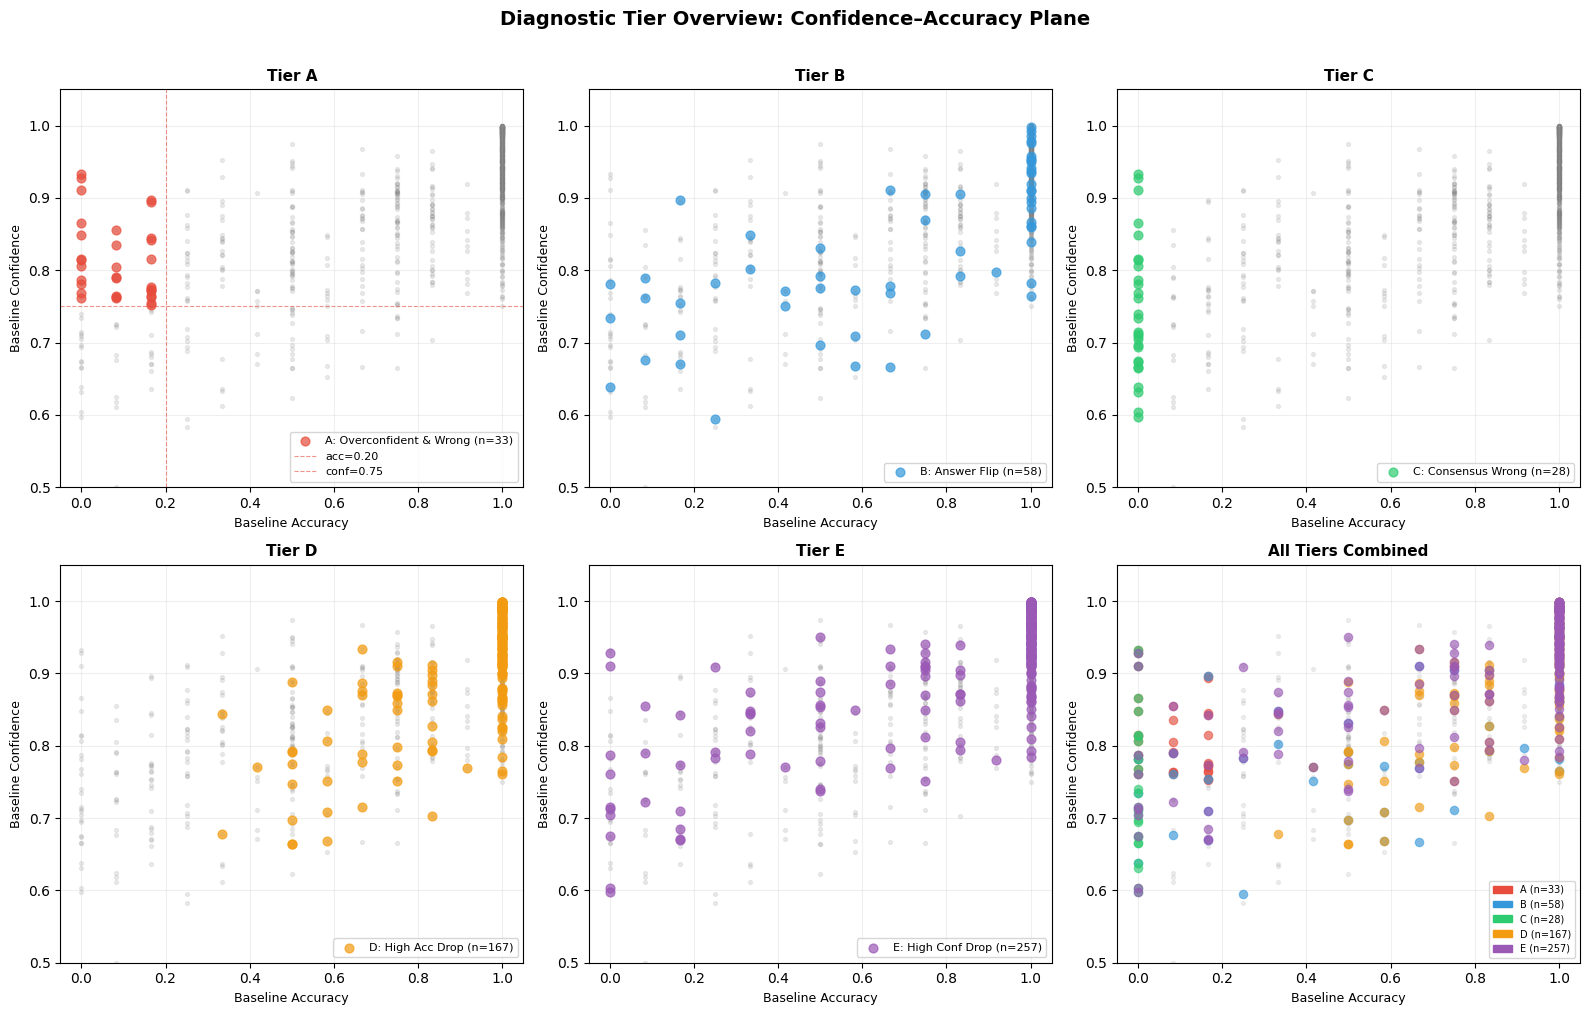

Spatial patterns in the confidence–accuracy plane:
  Tier A (red):    Top-left corner — high confidence, low accuracy = hallucination zone
  Tier C (green):  Left cluster — all models wrong, regardless of confidence level
  Tier B (blue):   Scattered across plane — answer flip is independent of absolute accuracy


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

FIGURES_DIR = '/home/david/Desktop/yuna/HPA/analysis/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

tier_info = {
    'A': {'mask': qdf['overconfident_wrong'],          'color': '#e74c3c', 'label': 'A: Overconfident & Wrong'},
    'B': {'mask': qdf['mean_output_changes'] > 2,      'color': '#3498db', 'label': 'B: Answer Flip'},
    'C': {'mask': qdf['consensus_wrong'],               'color': '#2ecc71', 'label': 'C: Consensus Wrong'},
    'D': {'mask': qdf['acc_drop'] > 0.3,               'color': '#f39c12', 'label': 'D: High Acc Drop'},
    'E': {'mask': qdf['conf_drop'] > 0.05,             'color': '#9b59b6', 'label': 'E: High Conf Drop'},
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Diagnostic Tier Overview: Confidence–Accuracy Plane', fontsize=14, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

for idx, (tier_key, info) in enumerate(tier_info.items()):
    ax = axes_flat[idx]
    # Background: all 1K questions
    ax.scatter(qdf['acc_baseline'], qdf['conf_baseline'], s=8, alpha=0.15, color='gray', zorder=1)
    # Highlighted tier
    subset = qdf[info['mask']]
    ax.scatter(subset['acc_baseline'], subset['conf_baseline'],
               s=40, alpha=0.7, color=info['color'], zorder=2,
               label=f"{info['label']} (n={len(subset)})")
    # Tier A thresholds
    if tier_key == 'A':
        ax.axvline(0.2, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6, label='acc=0.20')
        ax.axhline(0.75, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6, label='conf=0.75')
    ax.set_xlabel('Baseline Accuracy', fontsize=9)
    ax.set_ylabel('Baseline Confidence', fontsize=9)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(f'Tier {tier_key}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)

# Combined panel
ax_all = axes_flat[5]
ax_all.scatter(qdf['acc_baseline'], qdf['conf_baseline'], s=8, alpha=0.12, color='gray', zorder=1)
handles = []
for tier_key, info in tier_info.items():
    subset = qdf[info['mask']]
    ax_all.scatter(subset['acc_baseline'], subset['conf_baseline'],
                   s=35, alpha=0.6, color=info['color'], zorder=2)
    handles.append(mpatches.Patch(color=info['color'], label=f"{info['label'].split(':')[0]} (n={len(subset)})"))
ax_all.set_xlabel('Baseline Accuracy', fontsize=9)
ax_all.set_ylabel('Baseline Confidence', fontsize=9)
ax_all.set_xlim(-0.05, 1.05)
ax_all.set_ylim(0.5, 1.05)
ax_all.legend(handles=handles, fontsize=7, loc='lower right')
ax_all.set_title('All Tiers Combined', fontsize=11, fontweight='bold')
ax_all.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tier_overview_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Spatial patterns in the confidence–accuracy plane:")
print("  Tier A (red):    Top-left corner — high confidence, low accuracy = hallucination zone")
print("  Tier C (green):  Left cluster — all models wrong, regardless of confidence level")
print("  Tier B (blue):   Scattered across plane — answer flip is independent of absolute accuracy")


In [8]:
# Build review_df: one row per question with per-model outputs for baseline ('question' variant)
model_outputs = df[df['control_type'] == 'question'].pivot_table(
    index='question_id', columns='model', values='output', aggfunc='first'
).reset_index()

review_df = qdf.merge(model_outputs, on='question_id')
review_df = review_df.merge(
    df[df['control_type'] == 'question'][['question_id', 'question_text', 'gt_answer']].drop_duplicates('question_id'),
    on='question_id'
)

MODEL_COLS = sorted(df['model'].unique().tolist())

def clean_q(s):
    s = str(s)
    for strip in ['Question: ', ' Answer the question using a single word or phrase.', '\nAnswer:']:
        s = s.replace(strip, '')
    return s.strip()[:90]

def fmt_gt(gt):
    if isinstance(gt, list):
        unique = list(dict.fromkeys(str(a) for a in gt))
        return ', '.join(unique[:3]) + ('…' if len(unique) > 3 else '')
    return str(gt)[:40]

# Tier A: top 6 by confidence
tier_a_ids = sampled_df[sampled_df['tiers'].str.contains('A_')]['question_id'].tolist()
tier_a_df  = review_df[review_df['question_id'].isin(tier_a_ids)].sort_values('conf_baseline', ascending=False).head(6)

display_a = tier_a_df[['question_id', 'ent', 'conf_baseline', 'acc_baseline', 'question_text', 'gt_answer'] + MODEL_COLS].copy()
display_a['Q']        = display_a['question_text'].apply(clean_q)
display_a['GT']       = display_a['gt_answer'].apply(fmt_gt)
display_a = display_a[['question_id', 'ent', 'Q', 'GT', 'conf_baseline', 'acc_baseline'] + MODEL_COLS]

from IPython.display import display as ipy_display
styled = (display_a.style
    .background_gradient(subset=['conf_baseline'], cmap='Reds',   vmin=0.5, vmax=1.0)
    .background_gradient(subset=['acc_baseline'],  cmap='Greens', vmin=0.0, vmax=1.0)
    .format({'conf_baseline': '{:.3f}', 'acc_baseline': '{:.3f}'})
    .set_caption('Tier A — Overconfident & Wrong (top 6 by confidence, 4-model ensemble)')
)
ipy_display(styled)

,question_id,ent,Q,GT,conf_baseline,acc_baseline,Qwen3-VL-2B-Instruct,Qwen3-VL-4B-Instruct,llava-v1.6-vicuna-13b-hf,llava-v1.6-vicuna-7b-hf
251,158279002,text,What is the web address listed?,"foodiebakercom, http://foodiebakercom",0.928,0.000,http://foodiebaker.com,HTTP://FOODIEBAKER.COM,Wwwfoodiebakercom,Wwwfoodiebakercom
844,525021007,person,Does everyone have helmets on?,yes,0.910,0.000,no,no,No,No
24,13546003,object,How many benches are in the background?,"4, 3, 0…",0.897,0.167,2,3,2,2
195,126583001,person,What does the man have in his right hand?,"towel, tennis racquet, glove…",0.894,0.167,tennis racket,tennis racket,Racket,Racket
828,519471003,text,What is the name on the banner?,"ack hostingcom, jack hostingcom, ack hosting",0.866,0.000,ackhosting.com,ackhosting.com,Ackhostingcom,Backhostingcom
76,55772003,object,What is on the plate?,"egg and canadian bacon, pancakes and bacon, ham and cheese melt…",0.855,0.083,pancakes,pancakes and bacon,Pancake,Pancake


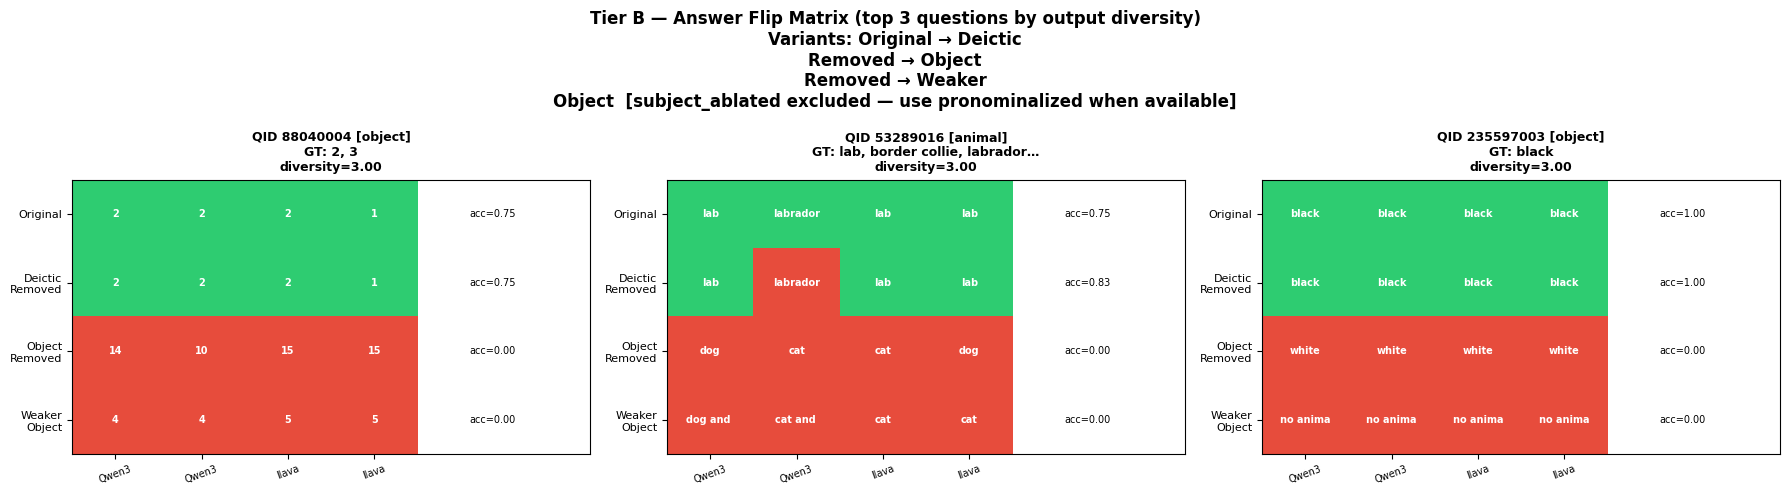

Insight: Answer changes when linguistic triggers are removed reveal that models respond
to question surface form, not semantic content. Green = matches baseline; red = flipped answer.

Note: subject_ablated excluded. Re-run with pronominalized once inference is complete.


In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

CT_LABELS = {
    'question':        'Original',
    'deictic_removed': 'Deictic\nRemoved',
    'object_removed':  'Object\nRemoved',
    'weaker_object':   'Weaker\nObject',
    # subject_ablated removed — deprecated; pronominalized not yet available
}
# Use CONTROL_TYPES from cell 1 (excludes subject_ablated)

# Top 3 Tier B questions by mean_output_changes
tier_b_ids = sampled_df[sampled_df['tiers'].str.contains('B_')].sort_values(
    'mean_output_changes', ascending=False)['question_id'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Tier B — Answer Flip Matrix (top 3 questions by output diversity)\n'
             f'Variants: {" → ".join(CT_LABELS.values())}  [subject_ablated excluded — use pronominalized when available]',
             fontsize=12, fontweight='bold')

for ax_idx, qid in enumerate(tier_b_ids):
    ax = axes[ax_idx]
    
    # Baseline answer (from review_df)
    baseline_row = review_df[review_df['question_id'] == qid].iloc[0]
    baseline_answers = {m: str(baseline_row.get(m, '')).lower().strip() for m in MODEL_COLS}
    
    # Per-variant outputs from df — filter to current CONTROL_TYPES only
    q_data = df[
        (df['question_id'] == qid) &
        (df['model'].isin(MODEL_COLS)) &
        (df['control_type'].isin(CONTROL_TYPES))
    ].pivot_table(
        index='control_type', columns='model', values='output', aggfunc='first'
    ).reindex(CONTROL_TYPES)
    
    # Per-variant accuracy from agg
    acc_data = agg[(agg['question_id'] == qid)].set_index('control_type')['mean_accuracy'].reindex(CONTROL_TYPES)
    
    n_ct = len(CONTROL_TYPES)
    n_m  = len(MODEL_COLS)
    color_matrix = np.zeros((n_ct, n_m))
    text_matrix  = []
    
    for r, ct in enumerate(CONTROL_TYPES):
        row_texts = []
        for c, m in enumerate(MODEL_COLS):
            if ct in q_data.index and m in q_data.columns:
                val = str(q_data.loc[ct, m]).lower().strip() if pd.notna(q_data.loc[ct, m]) else ''
            else:
                val = ''
            base_ans = baseline_answers.get(m, '')
            color_matrix[r, c] = 1.0 if (val == base_ans and val != '') else 0.0
            row_texts.append(val[:8])
        text_matrix.append(row_texts)
    
    # Heatmap: green=matches baseline, red=different
    cmap = mcolors.LinearSegmentedColormap.from_list('flip', ['#e74c3c', '#2ecc71'])
    ax.imshow(color_matrix, cmap=cmap, vmin=0, vmax=1, aspect='auto')
    
    for r in range(n_ct):
        for c in range(n_m):
            ax.text(c, r, text_matrix[r][c], ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
        # Right-margin acc annotation
        acc_val = acc_data.iloc[r] if r < len(acc_data) else float('nan')
        ax.text(n_m + 0.1, r, f'acc={acc_val:.2f}' if pd.notna(acc_val) else 'acc=N/A',
                va='center', fontsize=7, color='black')
    
    ax.set_xticks(range(n_m))
    ax.set_xticklabels([m.split('-')[0][:12] for m in MODEL_COLS], fontsize=7, rotation=20)
    ax.set_yticks(range(n_ct))
    ax.set_yticklabels([CT_LABELS[ct] for ct in CONTROL_TYPES], fontsize=8)
    ax.set_xlim(-0.5, n_m + 1.5)
    
    # Entity and GT
    row_info = sampled_df[sampled_df['question_id'] == qid].iloc[0]
    gt_sample = fmt_gt(baseline_row['gt_answer'])
    diversity = row_info['mean_output_changes']
    ax.set_title(f'QID {qid} [{row_info["ent"]}]\nGT: {gt_sample}\ndiversity={diversity:.2f}',
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tier_b_flip_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Answer changes when linguistic triggers are removed reveal that models respond")
print("to question surface form, not semantic content. Green = matches baseline; red = flipped answer.")
print(f"\nNote: subject_ablated excluded. Re-run with pronominalized once inference is complete.")

ValueError: could not convert string to float: '100%'

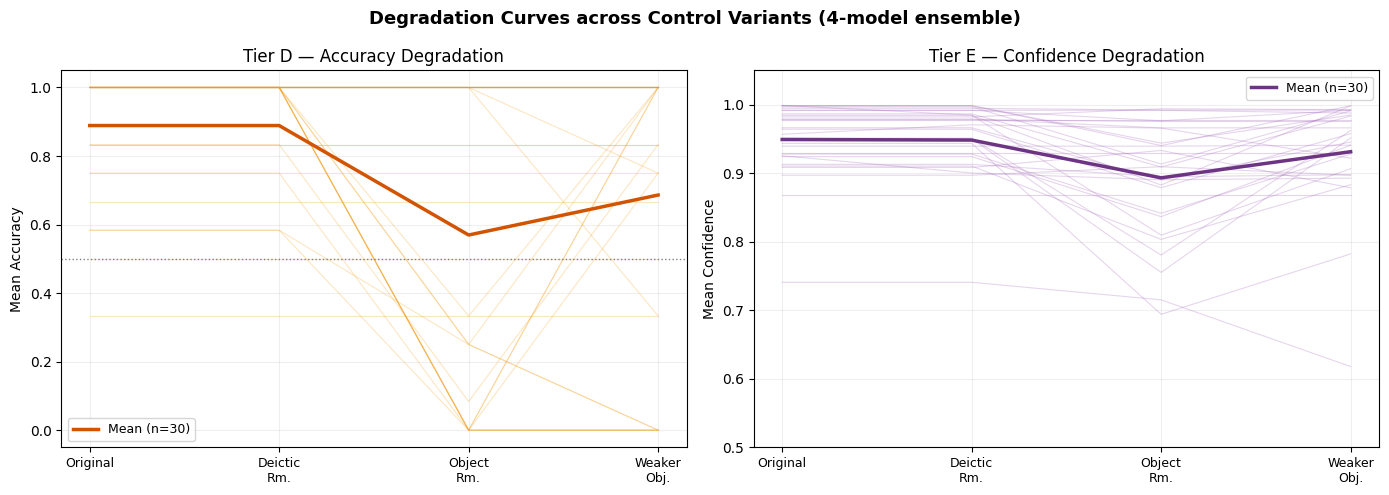

In [10]:
import matplotlib.pyplot as plt
from IPython.display import display as ipy_display

CT_AXIS_LABELS = ['Original', 'Deictic\nRm.', 'Object\nRm.', 'Weaker\nObj.']
x = range(len(CONTROL_TYPES))

# ── Tier C: top 6 by frac_models_wrong ──────────────────────────────────────
tier_c_ids = sampled_df[sampled_df['tiers'].str.contains('C_')].sort_values(
    'frac_models_wrong', ascending=False)['question_id'].head(6).tolist()
tier_c_df = review_df[review_df['question_id'].isin(tier_c_ids)].sort_values('frac_models_wrong', ascending=False)

display_c = tier_c_df[['question_id', 'ent', 'question_text', 'gt_answer', 'frac_models_wrong'] + MODEL_COLS].copy()
display_c['Q']      = display_c['question_text'].apply(clean_q)
display_c['GT']     = display_c['gt_answer'].apply(fmt_gt)
display_c['% wrong'] = display_c['frac_models_wrong'].map('{:.0%}'.format)
ipy_display(display_c[['question_id', 'ent', 'Q', 'GT', '% wrong'] + MODEL_COLS].style
    .background_gradient(subset=['% wrong'], cmap='Reds')
    .set_caption('Tier C — Cross-Model Consensus Wrong (top 6)'))

# ── Tier D & E: Degradation Curves ──────────────────────────────────────────
fig, (ax_d, ax_e) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Degradation Curves across Control Variants (4-model ensemble)', fontsize=13, fontweight='bold')

# Tier D — accuracy
tier_d_ids = sampled_df[sampled_df['tiers'].str.contains('D_')]['question_id'].tolist()
tier_d_curves = []
for qid in tier_d_ids:
    q_agg = agg[(agg['question_id'] == qid)].set_index('control_type')['mean_accuracy'].reindex(CONTROL_TYPES)
    if q_agg.notna().sum() >= 3:
        tier_d_curves.append(q_agg.values)
        ax_d.plot(x, q_agg.values, color='#f39c12', alpha=0.25, linewidth=0.8)
if tier_d_curves:
    mean_d = np.nanmean(tier_d_curves, axis=0)
    ax_d.plot(x, mean_d, color='#d35400', linewidth=2.5, label=f'Mean (n={len(tier_d_curves)})', zorder=5)
ax_d.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax_d.set_xticks(list(x)); ax_d.set_xticklabels(CT_AXIS_LABELS, fontsize=9)
ax_d.set_ylabel('Mean Accuracy'); ax_d.set_ylim(-0.05, 1.05)
ax_d.set_title('Tier D — Accuracy Degradation'); ax_d.legend(fontsize=9); ax_d.grid(True, alpha=0.2)

# Tier E — confidence
tier_e_ids = sampled_df[sampled_df['tiers'].str.contains('E_')]['question_id'].tolist()
tier_e_curves = []
for qid in tier_e_ids:
    q_agg = agg[(agg['question_id'] == qid)].set_index('control_type')['mean_confidence'].reindex(CONTROL_TYPES)
    if q_agg.notna().sum() >= 3:
        tier_e_curves.append(q_agg.values)
        ax_e.plot(x, q_agg.values, color='#9b59b6', alpha=0.25, linewidth=0.8)
if tier_e_curves:
    mean_e = np.nanmean(tier_e_curves, axis=0)
    ax_e.plot(x, mean_e, color='#6c3483', linewidth=2.5, label=f'Mean (n={len(tier_e_curves)})', zorder=5)
ax_e.set_xticks(list(x)); ax_e.set_xticklabels(CT_AXIS_LABELS, fontsize=9)
ax_e.set_ylabel('Mean Confidence'); ax_e.set_ylim(0.5, 1.05)
ax_e.set_title('Tier E — Confidence Degradation'); ax_e.legend(fontsize=9); ax_e.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tier_d_e_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

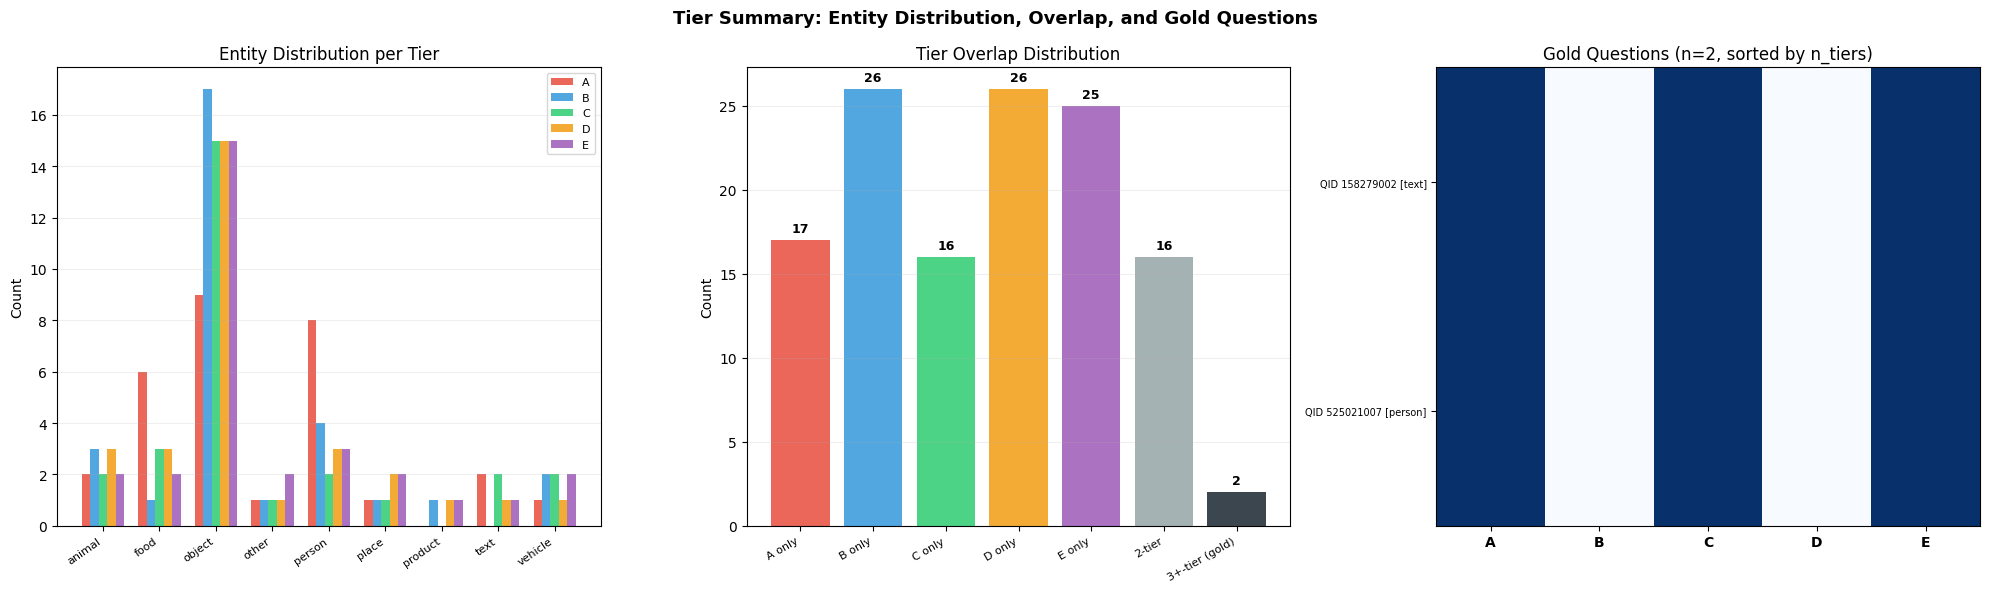

Gold questions (3+ tiers): 2
Gold questions should be prioritized for the human study — they simultaneously probe
multiple failure modes and provide the richest signal about whether humans share the
model's biases.


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

TIER_KEYS  = ['A', 'B', 'C', 'D', 'E']
TIER_NAMES = {'A': 'A_overconfident_wrong', 'B': 'B_answer_flip', 'C': 'C_consensus_wrong',
              'D': 'D_high_acc_drop', 'E': 'E_high_conf_drop'}
TIER_COLORS = {'A': '#e74c3c', 'B': '#3498db', 'C': '#2ecc71', 'D': '#f39c12', 'E': '#9b59b6'}
ENT_CATS   = sorted(qdf['ent'].dropna().unique())

# ── Entity distribution per tier ─────────────────────────────────────────────
tier_ent = {}
for t in TIER_KEYS:
    name = TIER_NAMES[t]
    ids = sampled_df[sampled_df['tiers'].str.contains(name)]['question_id'].tolist()
    sub = sampled_df[sampled_df['question_id'].isin(ids)]
    tier_ent[t] = sub['ent'].value_counts().reindex(ENT_CATS, fill_value=0)

# ── Tier overlap ──────────────────────────────────────────────────────────────
overlap_counts = {'A only': 0, 'B only': 0, 'C only': 0, 'D only': 0, 'E only': 0,
                  '2-tier': 0, '3+-tier (gold)': 0}
for _, row in sampled_df.iterrows():
    n = row['n_tiers']
    if n == 1:
        t = row['tiers'].split('_')[0]
        overlap_counts[f'{t} only'] += 1
    elif n == 2:
        overlap_counts['2-tier'] += 1
    else:
        overlap_counts['3+-tier (gold)'] += 1

# ── Gold questions ────────────────────────────────────────────────────────────
gold_df = sampled_df[sampled_df['n_tiers'] >= 3].sort_values('n_tiers', ascending=False).head(20)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Tier Summary: Entity Distribution, Overlap, and Gold Questions',
             fontsize=13, fontweight='bold')

# Left — grouped bar chart
bar_width = 0.15
ent_x = np.arange(len(ENT_CATS))
for i, t in enumerate(TIER_KEYS):
    ax1.bar(ent_x + i * bar_width, tier_ent[t].values, width=bar_width,
            label=t, color=TIER_COLORS[t], alpha=0.85)
ax1.set_xticks(ent_x + bar_width * 2)
ax1.set_xticklabels(ENT_CATS, rotation=35, ha='right', fontsize=8)
ax1.set_ylabel('Count')
ax1.set_title('Entity Distribution per Tier')
ax1.legend(fontsize=8)
ax1.grid(True, axis='y', alpha=0.2)

# Middle — tier overlap bars
bar_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#95a5a6','#1a252f']
bars = ax2.bar(range(len(overlap_counts)), list(overlap_counts.values()),
               color=bar_colors, alpha=0.85)
for bar, val in zip(bars, overlap_counts.values()):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(range(len(overlap_counts)))
ax2.set_xticklabels(list(overlap_counts.keys()), rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Count')
ax2.set_title('Tier Overlap Distribution')
ax2.grid(True, axis='y', alpha=0.2)

# Right — gold question heatmap
tier_binary = np.zeros((len(gold_df), len(TIER_KEYS)))
for r_idx, (_, row) in enumerate(gold_df.iterrows()):
    for c_idx, t in enumerate(TIER_KEYS):
        if TIER_NAMES[t] in row['tiers']:
            tier_binary[r_idx, c_idx] = 1.0

ax3.imshow(tier_binary, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax3.set_xticks(range(len(TIER_KEYS)))
ax3.set_xticklabels(TIER_KEYS, fontsize=10, fontweight='bold')
ytick_labels = [f"QID {row['question_id']} [{row['ent']}]"
                for _, row in gold_df.iterrows()]
ax3.set_yticks(range(len(gold_df)))
ax3.set_yticklabels(ytick_labels, fontsize=7)
ax3.set_title(f'Gold Questions (n={len(gold_df)}, sorted by n_tiers)')
ax3.grid(False)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tier_summary.png', dpi=150, bbox_inches='tight')
plt.show()

gold_count = overlap_counts['3+-tier (gold)']
print(f"Gold questions (3+ tiers): {gold_count}")
print("Gold questions should be prioritized for the human study — they simultaneously probe")
print("multiple failure modes and provide the richest signal about whether humans share the")
print("model's biases.")


In [12]:
# Export for manual review / human study design
out_path = '/home/david/Desktop/yuna/HPA/analysis/csv/sampled_control_questions.csv'
review_df.to_csv(out_path, index=False)
print(f'Saved {len(review_df)} questions to {out_path}') 

Saved 925 questions to /home/david/Desktop/yuna/HPA/analysis/csv/sampled_control_questions.csv
